# Statistical Inference and Testing

## 📚 Learning Objectives

By completing this notebook, you will:
- Perform basic statistical inference
- Use point estimates, CIs, and hypothesis tests
- Interpret results in ML context

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — you computed statistics on 891 real passengers; inference is what lets you say something about the population behind a sample.

**Used later in:** Course 04 (AIAT 114) — Unit 2 — deciding whether one model's cross-validation score really beats another's.

---


---

## 📌 Real case: why an A/B result gets believed — or thrown away

Online experimentation is statistical inference wearing a business suit. In *"The Surprising Power of
Online Experiments"* (Harvard Business Review, September–October 2017), Ron Kohavi — who ran
experimentation at Amazon and then at Microsoft — and Stefan Thomke report two findings that belong
together.

The first: in 2012 a Bing engineer proposed a small change to how ad headlines were displayed. It was rated
low priority and sat unimplemented for months until someone ran it as an A/B test. It **increased revenue
by about 12%** which, in the authors' words, "on an annual basis would come to more than **$100 million in
the United States alone**" — the best revenue-generating idea in Bing's history, and nobody had thought it
was interesting.

The second: at Microsoft, roughly **one third** of tested ideas improve the metric they were designed to
improve, one third do nothing, and one third make it worse.

Both halves are inference problems. "Two thirds of confident, expert ideas fail" is why you run the test at
all. "This result looks too good — check the instrumentation" is why you must know what a difference of that
size would look like under chance before you believe one.

**What goes wrong without this.** Without a sampling distribution you cannot tell a real improvement from a
lucky week, so you ship changes that do nothing and abandon changes that worked. The cells below build
exactly that machinery on real model scores: 100 cross-validation splits, a mean, and an interval that says
how far the mean itself could reasonably have landed.


# Statistical Inference and Testing

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Probability Distributions** - Understand distributions
- ✅ **Basic statistics**: Mean, variance, standard deviation

> **Note on ordering**: This notebook is an *overview*. Sampling distributions, hypothesis tests, p-values, and confidence intervals are each taught fully later in this unit (notebooks 04-05 and 07-08). The bridge section below gives you just enough to follow the example — don't worry if the details feel new here.


---

## 🔗 Where This Notebook Fits

**This is the SECOND example of Module 05** - testing hypotheses!

**Why this example SECOND?**
- **Before** you can test hypotheses, you need distributions (Example 1)
- **Before** you can make conclusions, you need statistical tests

**Builds on**: Example 1 (distributions)

**Leads to**: Example 3: Bayesian Inference

---

## The Story: Understanding Before Using

Imagine testing if a new medicine works. **Before** you can conclude, you need statistical tests. **After** understanding statistical inference, you can make confident conclusions!

Same with machine learning: **Before** comparing models, we need statistical tests. **After** understanding inference, we can statistically compare models!

---

## Why This Concept Matters

### Why Statistical Inference Matters

**WHY** is inference essential?

1. **Model Comparison**:
   - **WHY**: Need to know if one model is better
   - **HOW**: Use statistical tests
   - **AFTER**: Can make confident comparisons

2. **Confidence Intervals**:
   - **WHY**: Need to quantify uncertainty
   - **HOW**: Compute confidence intervals
   - **AFTER**: Can provide uncertainty estimates

3. **Hypothesis Testing**:
   - **WHY**: Need to test assumptions
   - **HOW**: Use statistical tests
   - **AFTER**: Can make statistical conclusions

## Learning Objectives
1. Understand hypothesis testing
2. Understand p-values
3. Compute confidence intervals
4. Apply to ML model evaluation

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, plus sklearn to produce REAL
# model-performance numbers by cross-validating a classifier on a real dataset.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

---

## 🌉 Bridge: Where "mean ± 1.96 × SE" Comes From

Here is the minimum background needed for the example below (full derivations come in notebook 04 — Central Limit Theorem, 05 — sampling and standard error, and 08 — confidence intervals and p-values):

1. **A statistic varies from sample to sample.** If we measure a model's accuracy over 100 runs and average, repeating the whole experiment would give a slightly different average each time. The distribution of that average across hypothetical repeats is the **sampling distribution of the mean**.
2. **Standard error (SE).** The standard deviation of that sampling distribution is the **standard error**: SE = σ/√n, where σ is the spread of the individual scores and n is how many scores we averaged. More scores → smaller SE → a more precise estimate.
3. **Where 1.96 comes from.** For a normal distribution, 95% of values fall within ±1.96 standard deviations of the mean. So *mean ± 1.96 × SE* is a range that captures the true mean in about 95% of repeated experiments — the **95% confidence interval**.

The next cell verifies points 2 and 3 by simulation before we use them.

In [2]:
# Bridge demo: verify SE = sigma/sqrt(n) and the 1.96 rule by simulation
np.random.seed(0)
true_mean, sigma, n_runs, n_repeats = 0.85, 0.03, 100, 2000

# Repeat the "measure accuracy over 100 runs and average" experiment 2000 times
sample_means = np.random.normal(true_mean, sigma, size=(n_repeats, n_runs)).mean(axis=1)

empirical_se = sample_means.std()
theoretical_se = sigma / np.sqrt(n_runs)
print(f"Empirical std of the sample means:  {empirical_se:.5f}")
print(f"Theoretical SE = sigma/sqrt(n):     {theoretical_se:.5f}")

# The 1.96 rule: ~95% of sample means fall within ±1.96 SE of the true mean
within = np.abs(sample_means - true_mean) <= 1.96 * theoretical_se
print(f"Fraction of sample means within ±1.96×SE: {within.mean():.1%} (expect ≈ 95%)")

Empirical std of the sample means:  0.00296
Theoretical SE = sigma/sqrt(n):     0.00300
Fraction of sample means within ±1.96×SE: 94.8% (expect ≈ 95%)


## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [3]:
# Example 1: Statistical Inference on REAL model performance
# WHY: Need to make statistical conclusions about how good a model is
# HOW: Use repeated cross-validation to get a real distribution of scores,
#      then summarise it with confidence intervals

# Real dataset: 569 breast-tumour biopsies with 30 measurements each.
cancer = load_breast_cancer()
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

# 5-fold cross-validation repeated 20 times = 100 genuine train/validation splits.
# Each split gives one real training accuracy and one real validation accuracy.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=0)
results = cross_validate(model, cancer.data, cancer.target, cv=cv, return_train_score=True)

train_scores = results["train_score"]   # 100 real accuracies, measured not invented
val_scores = results["test_score"]

# Compute means and confidence intervals
train_mean = np.mean(train_scores)
train_std = np.std(train_scores)
val_mean = np.mean(val_scores)
val_std = np.std(val_scores)

n = len(train_scores)
train_ci = 1.96 * train_std / np.sqrt(n)  # 95% CI half-width = 1.96 x SE
val_ci = 1.96 * val_std / np.sqrt(n)

print("Example 1: Statistical Inference")
print("=" * 60)
print(f"Model: standardized logistic regression on {cancer.data.shape[0]} real biopsies")
print(f"Evidence: {n} cross-validation splits")
print(f"\nTraining accuracy: {train_mean:.2%} ± {train_ci:.2%} (95% CI)")
print(f"Validation accuracy: {val_mean:.2%} ± {val_ci:.2%} (95% CI)")
print(f"\nGap (train - validation): {train_mean - val_mean:.2%} - the price of fitting the")
print("training folds. Real, small, and worth knowing before anyone reports a single number.")
print(f"\n💡 WHY: Quantify uncertainty in model performance")
print(f"💡 HOW: Use confidence intervals (mean ± 1.96×SE)")
print(f"💡 AFTER: Can provide uncertainty estimates!")


Example 1: Statistical Inference
Model: standardized logistic regression on 569 real biopsies
Evidence: 100 cross-validation splits

Training accuracy: 98.87% ± 0.06% (95% CI)
Validation accuracy: 97.65% ± 0.28% (95% CI)

Gap (train - validation): 1.22% - the price of fitting the
training folds. Real, small, and worth knowing before anyone reports a single number.

💡 WHY: Quantify uncertainty in model performance
💡 HOW: Use confidence intervals (mean ± 1.96×SE)
💡 AFTER: Can provide uncertainty estimates!


### 🧪 How much evidence does a confidence interval need?

Baseline: the 100 cross-validation splits above. Change one thing: use only the first *m* of them.
Measure: the 95% CI half-width, and whether it shrinks the way the σ/√m formula says it should.

In [4]:
# Comparative experiment: confidence-interval width against the amount of evidence.

print(f"{'splits used':>12} {'mean accuracy':>15} {'95% CI half-width':>20} {'interval':>24}")
print("-" * 76)
widths = {}
for m in [5, 10, 25, 50, 100]:
    sub = val_scores[:m]
    half = 1.96 * sub.std(ddof=1) / np.sqrt(m)
    widths[m] = half
    print(f"{m:>12} {sub.mean():>14.4f} {half:>20.4f}   "
          f"[{sub.mean() - half:.4f}, {sub.mean() + half:.4f}]")

print()
print("Predicted by the formula: the width should shrink like 1/sqrt(m).")
for a, b in [(5, 25), (25, 100), (5, 100)]:
    print(f"   {a:>3} -> {b:>3} splits: predicted {np.sqrt(b / a):.2f}x narrower, "
          f"observed {widths[a] / widths[b]:.2f}x")
print()
print("Conclusion the numbers support: the interval narrows roughly like 1/sqrt(m), so precision is")
print("expensive - each extra decimal place costs a hundredfold more evidence. Two cautions come")
print("with that. First, the observed ratio will not match the predicted one exactly, because the")
print("estimated standard deviation itself wobbles when m is small. Second, and more seriously,")
print("these 100 splits are NOT independent - they reuse the same 569 patients - so every width in")
print("this table is narrower than the truth. More cross-validation repeats buy you a more stable")
print("estimate of THIS dataset's score; they do not buy you more patients.")

 splits used   mean accuracy    95% CI half-width                 interval
----------------------------------------------------------------------------
           5         0.9789               0.0140   [0.9650, 0.9929]
          10         0.9754               0.0120   [0.9635, 0.9874]
          25         0.9772               0.0061   [0.9710, 0.9833]
          50         0.9772               0.0041   [0.9730, 0.9813]
         100         0.9765               0.0029   [0.9736, 0.9793]

Predicted by the formula: the width should shrink like 1/sqrt(m).
     5 ->  25 splits: predicted 2.24x narrower, observed 2.28x
    25 -> 100 splits: predicted 2.00x narrower, observed 2.14x
     5 -> 100 splits: predicted 4.47x narrower, observed 4.90x

Conclusion the numbers support: the interval narrows roughly like 1/sqrt(m), so precision is
expensive - each extra decimal place costs a hundredfold more evidence. Two cautions come
with that. First, the observed ratio will not match the predicted on

---

## 📊 Visualization

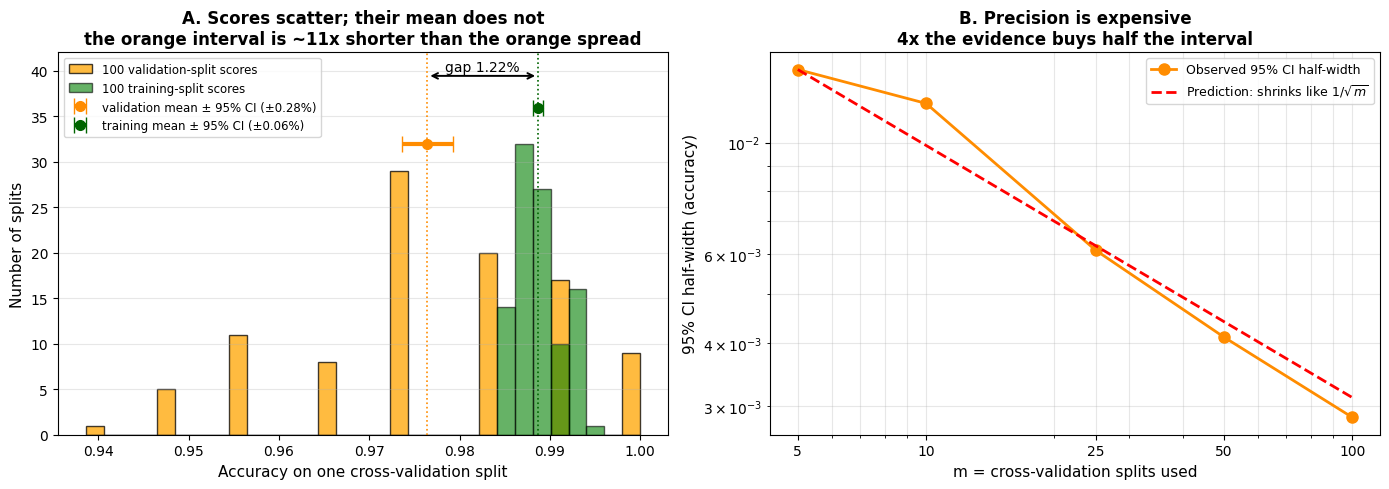


📊 Read the figure:
  A - the orange histogram spreads over 6.1% of accuracy: single splits disagree
      a lot. The short orange error bar floating above it is the 95% interval on their
      MEAN, ±0.28% - about 11 times shorter than that spread. Averaging many
      noisy measurements pins down the average, not the individual measurement.
  A - the green (training) marker sits to the RIGHT of the orange one - its interval is
      so short that it is barely wider than the dot itself - and the two do not overlap:
      the 1.22% gap marked by the black arrow is larger than the uncertainty
      in either mean, so it is a real gap, not noise.
  B - both axes are logarithmic, so a 1/sqrt(m) law is a straight line of slope -1/2.
      The measured half-widths (orange) track the red prediction, a little above it at
      m=10. Going from 5 to 100 splits shrank the interval 4.9x, for 20x the work.
  Caveat the figure cannot show: these splits reuse the same 569 patients, so every
  inter

In [5]:
# ONE figure for the two claims this notebook makes.
# WHY replace a plain bar chart: bars starting at 0.90 encode nothing, and error bars this
# small vanish inside them. What a student must SEE is (A) how far individual split scores
# scatter compared with how tightly the MEAN is pinned down, and (B) that buying precision
# costs evidence at the 1/sqrt(m) rate the table above printed.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: 100 real split scores, and the confidence interval on their mean -----------
bins = np.linspace(min(val_scores.min(), train_scores.min()), 1.0, 32)
axes[0].hist(val_scores, bins=bins, color='orange', alpha=0.75, edgecolor='black',
             label=f'{n} validation-split scores')
axes[0].hist(train_scores, bins=bins, color='green', alpha=0.6, edgecolor='black',
             label=f'{n} training-split scores')

# Draw the intervals ABOVE the histograms as short error bars: an interval on the MEAN is a
# different object from the spread of the scores, so it must not be drawn as if it were one.
counts, _ = np.histogram(val_scores, bins=bins)
ymax = counts.max()
axes[0].set_ylim(0, ymax * 1.45)
axes[0].errorbar(val_mean, ymax * 1.10, xerr=val_ci, fmt='o', color='darkorange',
                 capsize=6, elinewidth=3, markersize=7,
                 label=f'validation mean ± 95% CI (±{val_ci:.2%})')
axes[0].errorbar(train_mean, ymax * 1.24, xerr=train_ci, fmt='o', color='darkgreen',
                 capsize=6, elinewidth=3, markersize=7,
                 label=f'training mean ± 95% CI (±{train_ci:.2%})')
axes[0].axvline(val_mean, color='darkorange', linestyle=':', linewidth=1.2)
axes[0].axvline(train_mean, color='darkgreen', linestyle=':', linewidth=1.2)
axes[0].annotate('', xy=(val_mean, ymax * 1.36), xytext=(train_mean, ymax * 1.36),
                 arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.4))
axes[0].text((val_mean + train_mean) / 2, ymax * 1.38,
             f'gap {train_mean - val_mean:.2%}', ha='center', fontsize=10)

spread = val_scores.max() - val_scores.min()
ratio = spread / (2 * val_ci)
axes[0].set_xlabel('Accuracy on one cross-validation split', fontsize=11)
axes[0].set_ylabel('Number of splits', fontsize=11)
axes[0].set_title('A. Scores scatter; their mean does not\n'
                  f'the orange interval is ~{ratio:.0f}x shorter than the orange spread',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8.5, loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')

# --- Panel B: what the table in the previous cell claimed, drawn -------------------------
ms = np.array([5, 10, 25, 50, 100])
halves = np.array([1.96 * val_scores[:m].std(ddof=1) / np.sqrt(m) for m in ms])
axes[1].plot(ms, halves, 'o-', color='darkorange', linewidth=2, markersize=8,
             label='Observed 95% CI half-width')
axes[1].plot(ms, halves[0] * np.sqrt(ms[0] / ms), 'r--', linewidth=2,
             label=r'Prediction: shrinks like $1/\sqrt{m}$')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xticks(ms)
axes[1].set_xticklabels([str(m) for m in ms])
axes[1].set_xlabel('m = cross-validation splits used', fontsize=11)
axes[1].set_ylabel('95% CI half-width (accuracy)', fontsize=11)
axes[1].set_title('B. Precision is expensive\n'
                  '4x the evidence buys half the interval', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print(f"  A - the orange histogram spreads over {spread:.1%} of accuracy: single splits disagree")
print("      a lot. The short orange error bar floating above it is the 95% interval on their")
print(f"      MEAN, ±{val_ci:.2%} - about {ratio:.0f} times shorter than that spread. Averaging many")
print("      noisy measurements pins down the average, not the individual measurement.")
print("  A - the green (training) marker sits to the RIGHT of the orange one - its interval is")
print("      so short that it is barely wider than the dot itself - and the two do not overlap:")
print(f"      the {train_mean - val_mean:.2%} gap marked by the black arrow is larger than the uncertainty")
print("      in either mean, so it is a real gap, not noise.")
print("  B - both axes are logarithmic, so a 1/sqrt(m) law is a straight line of slope -1/2.")
print("      The measured half-widths (orange) track the red prediction, a little above it at")
print(f"      m=10. Going from 5 to 100 splits shrank the interval {halves[0]/halves[-1]:.1f}x, for 20x the work.")
print("  Caveat the figure cannot show: these splits reuse the same 569 patients, so every")
print("  interval drawn here is NARROWER than the truth. See '⚠️ Where this breaks' below.")


**📖 What to see in the figure above.** Panel A puts two things students routinely
confuse on one axis: the *spread of individual scores* (the histograms, several accuracy points
wide) and the *uncertainty in their mean* (the short error bars floating above them — the
training one so short it is barely wider than its marker). The two markers not overlapping,
with the arrow between them marking the gap, is what "the train–validation gap is statistically
real" actually looks like. Panel B is the table from the previous cell as a picture: on log–log
axes the σ/√m law is a straight line, and the measured widths track it, which is why the fourth
decimal place of an accuracy figure is almost never worth reporting.

---

## ⚠️ Where this breaks

- **The bridge simulation earns the 1.96, and the real data does not satisfy its assumption.** The demo
  cell draws 2,000 independent experiments and finds 94.8% of sample means inside ±1.96 SE — beautiful
  agreement with theory, *because the draws were independent*. The 100 cross-validation scores that follow
  are **not** independent: every fold shares training rows with every other fold, so the true standard error
  is larger than σ/√100 and the printed intervals (±0.06% train, ±0.28% validation) are too narrow. Course
  04, Unit 2 covers the corrected procedures.
- **A confidence interval covers sampling variation and nothing else.** It says nothing about whether these
  569 biopsies resemble the patients your hospital sees, whether the labels are correct, or whether the
  measurement instrument has drifted. A 95% CI on a biased estimate is a precise statement about the wrong
  number.
- **The 1.22% train–validation gap is a fact about this model and dataset, not a rule.** It is small
  because the dataset is small and clean and the model is heavily constrained. Read it as "here is how you
  measure the gap", not as "gaps of about 1% are normal."
- **Cheaper alternative when the assumptions worry you.** The bootstrap (Efron 1979, referenced in notebook
  05) computes an interval by resampling your data rather than by assuming a formula, and it does not need
  normality. It still needs independence.


---

## 💬 Discuss

1. The simulation gets 94.8% coverage; the real cross-validation intervals rest on an assumption the data
   violates. If you had to report *one* number for this model's accuracy to a hospital procurement
   committee, what would you report and what would you say about it?
2. Two thirds of tested ideas at Microsoft fail to move their target metric. What does that imply
   about a team that reports every experiment as a success — and about how you should design your own
   evaluation before you run it?
3. Training accuracy 98.87%, validation 97.65%, gap 1.22%, and the gap is statistically real. At what gap
   size would you actually change something, and what would you change?


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding statistical inference:

1. **Model Comparison**: Can statistically compare models
2. **Uncertainty Quantification**: Can provide confidence intervals
3. **Next Steps**: Learn Bayesian inference (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Student [Gosset, W. S.] (1908). *The Probable Error of a Mean*. Biometrika, 6(1), 1–25.
2. Neyman, J., & Pearson, E. S. (1933). *On the Problem of the Most Efficient Tests of Statistical Hypotheses*. Philosophical Transactions of the Royal Society A, 231, 289–337.
3. Wasserstein, R. L., & Lazar, N. A. (2016). *The ASA Statement on p-Values: Context, Process, and Purpose*. The American Statistician, 70(2), 129–133. <https://doi.org/10.1080/00031305.2016.1154108>
4. Miller, E. (2024). *Adding Error Bars to Evals: A Statistical Approach to Language Model Evaluations*. arXiv. <https://arxiv.org/abs/2411.00640> — classical inference applied to model evaluation: standard errors, paired comparisons, power.
5. Bowyer, S., Aitchison, L., & Ivanova, D. R. (2025). *Position: Don't Use the CLT in LLM Evals With Fewer Than a Few Hundred Datapoints*. arXiv. <https://arxiv.org/abs/2503.01747> — when the sample is small, CLT-based intervals underestimate uncertainty, with recommended alternatives.
